# Main

In [1]:
using Pkg
Pkg.add("Revise")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using Revise
includet("hamiltonian_path.jl")

Starting backtracking
Calculation of all conformations
Step 1: Exploration from the corner (node 1)
Step 2: Exploration from the center of the face (node 5)


In [3]:
using Revise
includet("visualization.jl")

In [4]:
using Revise
includet("metropolis.jl")

Starting backtracking
Calculation of all conformations
Step 1: Exploration from the corner (node 1)
Step 2: Exploration from the center of the face (node 5)


algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:11
algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


In [5]:
using Revise
includet("benchmark.jl")

Starting backtracking
Calculation of all conformations
Step 1: Exploration from the corner (node 1)
Step 2: Exploration from the center of the face (node 5)


algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:08
algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


## Hamiltonian paths

In [6]:
using .HamiltonianPath: PATHS, paths_to_file 

println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))


We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


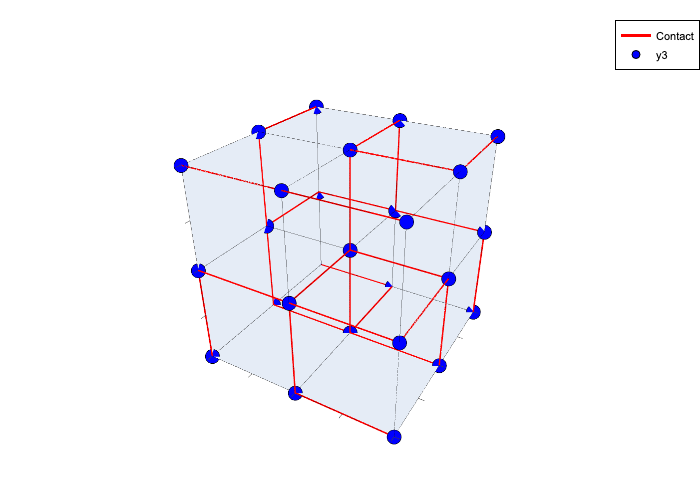

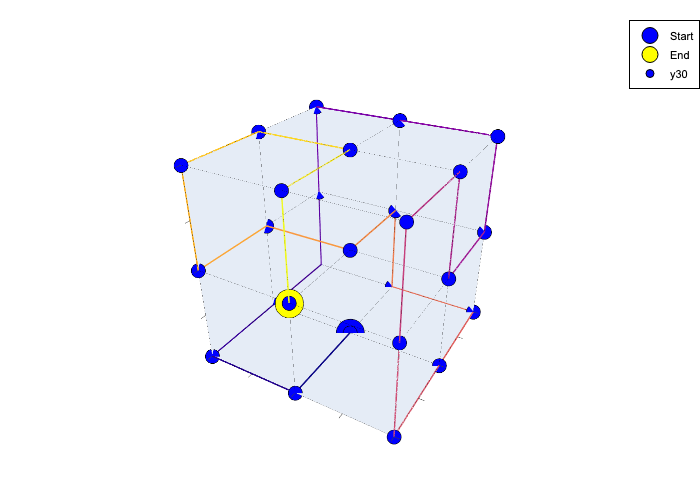

In [7]:
using .Visualization: contact_map, plot_cube_ctc_map, x, y, z, lx, ly, lz, plot_cube_path

println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


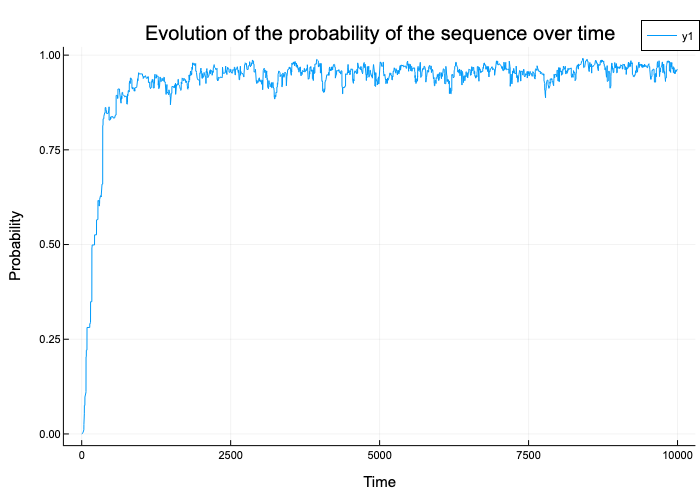

In [8]:
using .Metropolis: algo, all_ctc_maps, generate_seq
using Plots

seq = generate_seq()
target_number = 1234


final_seq, p_struct_time_t,_=algo(seq, target_number, all_ctc_maps, 10000, 100)
t=1:length(p_struct_time_t)
plot(t, p_struct_time_t, xlabel="Time", ylabel="Probability", title="Evolution of the probability of the sequence over time")

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


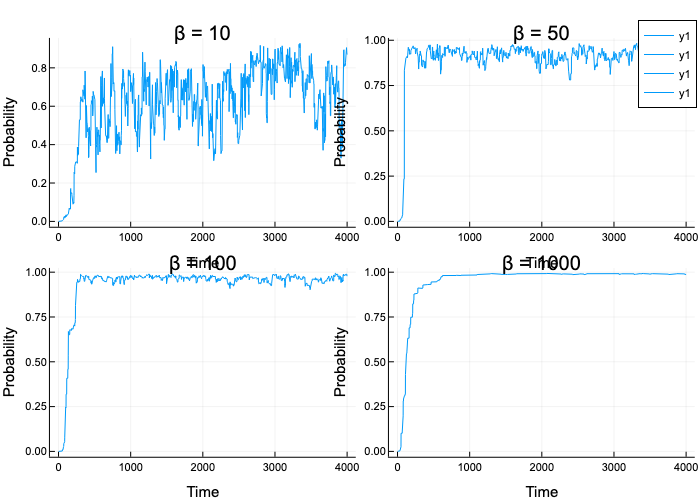

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([18, 11, 17, 15, 5, 2, 14, 2, 16, 17  …  19, 16, 1, 9, 4, 17, 7, 5…
  10.0   => ([3, 12, 7, 17, 11, 19, 16, 15, 9, 8  …  4, 20, 16, 19, 4, 14, 5, 1…
  1000.0 => ([3, 13, 18, 4, 16, 18, 5, 19, 19, 19  …  16, 15, 20, 17, 16, 7, 5,…
  100.0  => ([20, 17, 10, 15, 16, 5, 11, 11, 18, 15  …  16, 12, 15, 18, 1, 16, …

In [9]:
# benchmarking ß
using .Benchmark: benchmark_beta
benchmark_beta()


## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:01:08


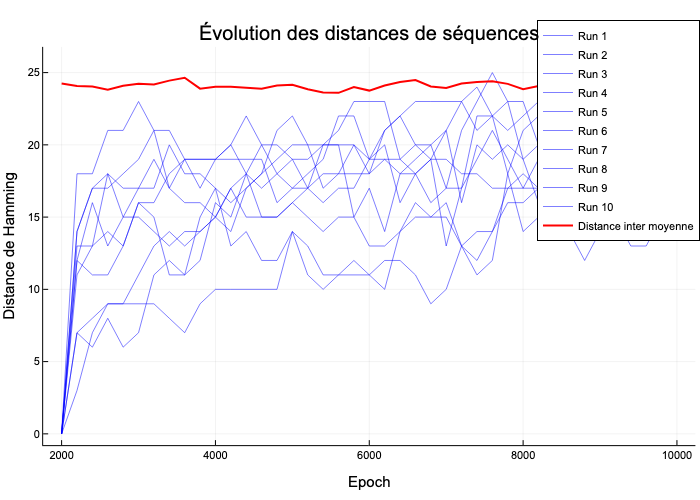

In [17]:
using .Benchmark: plot_distances_inter_intra, multi_init_seq_over_time

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=10000, beta=1000.0, threshold=2000, step=200, runs=10)

plot_distances_inter_intra(seq_over_time)

In [16]:
using .Benchmark:  multi_init_final_seq, calcul_dist_final

final_seqs = multi_init_final_seq(target_number, all_ctc_maps, beta=1000.0, runs=10)

calcul_dist_final(final_seqs)

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:01


45-element Vector{Int64}:
 26
 26
 24
 25
 27
 24
 22
 24
 25
 23
  ⋮
 26
 26
 26
 24
 25
 24
 26
 26
 26

### Probability comparison